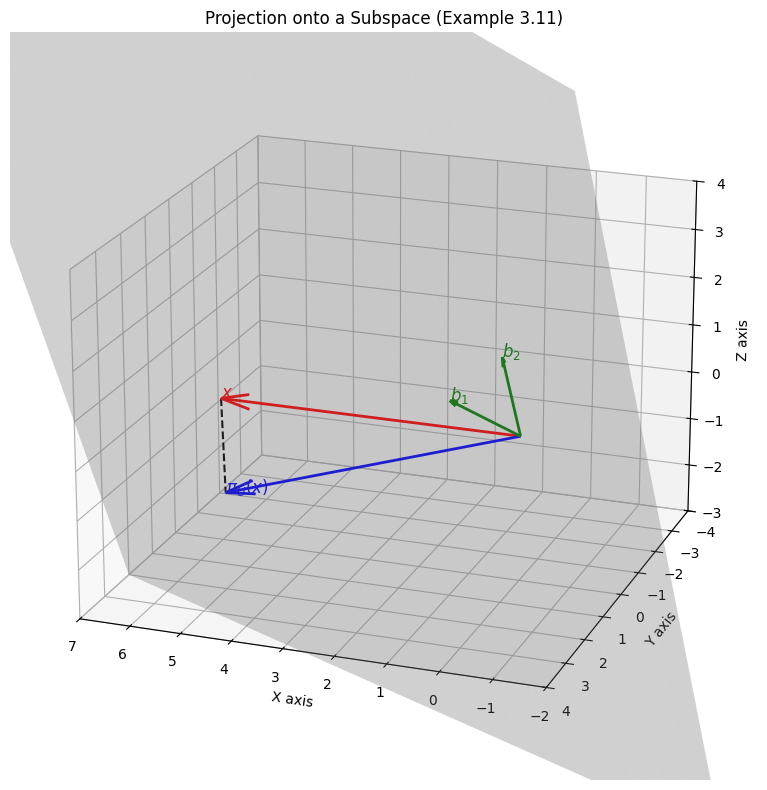

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. 데이터 정의 (예제 3.11의 값)
# 기저 벡터 b1, b2
b1 = np.array([1, 1, 1])
b2 = np.array([0, 1, 2])

# 원래 벡터 x
x_vec = np.array([6, 0, 0])

# 투영된 벡터 pi_U(x) (교재의 계산 결과)
# lambda = [5, -3] 이므로 5*b1 - 3*b2
proj_x = 5 * b1 - 3 * b2  # 결과: [5, 2, -1]

# 2. 평면(부분 공간 U) 생성
# 평면을 그리기 위해 격자(grid) 생성
# 투영점이 5*b1 - 3*b2 위치에 있으므로 범위를 이에 맞춰 설정
s = np.linspace(-2, 7, 20)  # b1 방향 계수 범위
t = np.linspace(-5, 5, 20)  # b2 방향 계수 범위
S, T = np.meshgrid(s, t)

# 평면 방정식: U = s*b1 + t*b2
X_plane = S * b1[0] + T * b2[0]
Y_plane = S * b1[1] + T * b2[1]
Z_plane = S * b1[2] + T * b2[2]

# 3. 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# (1) 부분 공간 U (평면) 그리기
ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.3, color='gray', edgecolor='none')
ax.text(X_plane[0,0], Y_plane[0,0], Z_plane[0,0], "Subspace U", color='gray')

# (2) 벡터 그리기 함수
def plot_vector(vec, origin, color, label):
    ax.quiver(origin[0], origin[1], origin[2], 
              vec[0], vec[1], vec[2], 
              color=color, arrow_length_ratio=0.1, linewidth=2)
    ax.text(vec[0], vec[1], vec[2], label, fontsize=12, color=color, fontweight='bold')

origin = np.array([0, 0, 0])

# 기저 벡터 b1, b2 (녹색)
plot_vector(b1, origin, 'green', '$b_1$')
plot_vector(b2, origin, 'green', '$b_2$')

# 원래 벡터 x (빨간색)
plot_vector(x_vec, origin, 'red', '$x$')

# 투영된 벡터 pi_U(x) (파란색)
plot_vector(proj_x, origin, 'blue', '$\pi_U(x)$')

# (3) 투영 오차 (점선) 그리기
# x의 끝점에서 투영점까지 연결하는 선
ax.plot([x_vec[0], proj_x[0]], 
        [x_vec[1], proj_x[1]], 
        [x_vec[2], proj_x[2]], 
        color='black', linestyle='--', linewidth=1.5, label='Error Vector')

# 4. 그래프 설정
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Projection onto a Subspace (Example 3.11)')

# 축 범위 조정 (잘 보이도록)
ax.set_xlim(-2, 7)
ax.set_ylim(-4, 4)
ax.set_zlim(-3, 4)

# 보는 각도 조정 (직교성이 잘 보이도록)
ax.view_init(elev=20, azim=110)

plt.tight_layout()
plt.savefig('projection_visualization.png')

In [1]:
'''
이 코드는 Plotly 라이브러리를 사용하여 예제 3.11의 투영 과정을 3D로 시각화합니다.
사용자는 생성된 그래프를 마우스로 회전, 확대, 축소할 수 있습니다.
핵심 요소:
1. 부분 공간 U (회색 평면): 기저 벡터 b1, b2에 의해 생성된 평면
2. 원래 벡터 x (빨간색): 공간 상에 떠 있는 점
3. 투영 벡터 pi_U(x) (파란색): 평면 위에 드리워진 그림자
4. 오차 벡터 (점선): x에서 평면으로 수직으로 떨어지는 최단 거리
'''

import numpy as np
import plotly.graph_objects as go

# 1. 데이터 정의 (예제 3.11의 값)
# 기저 벡터
b1 = np.array([1, 1, 1])
b2 = np.array([0, 1, 2])

# 원래 벡터 x
x_vec = np.array([6, 0, 0])

# 투영된 벡터 (계산된 결과: 5*b1 - 3*b2)
proj_x = np.array([5, 2, -1])

# 원점
origin = np.array([0, 0, 0])

# 2. 평면(부분 공간 U) 데이터 생성
# 평면을 형성하기 위한 파라미터 s, t의 범위 설정
# 투영 계수가 5와 -3이므로, 이 범위를 포함하도록 넉넉하게 잡습니다.
s_range = np.linspace(-1, 6, 20)
t_range = np.linspace(-4, 2, 20)
S, T = np.meshgrid(s_range, t_range)

# 평면의 좌표 계산 (Linear Combination)
X_plane = S * b1[0] + T * b2[0]
Y_plane = S * b1[1] + T * b2[1]
Z_plane = S * b1[2] + T * b2[2]

# 3. 그래프 생성
fig = go.Figure()

# (1) 부분 공간 U (평면) 추가
fig.add_trace(go.Surface(
    x=X_plane, y=Y_plane, z=Z_plane,
    colorscale='Greys', opacity=0.4, showscale=False,
    name='Subspace U'
))

# (2) 벡터를 그리는 함수 정의
def add_vector(fig, vec, color, name, show_legend=True):
    fig.add_trace(go.Scatter3d(
        x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]],
        mode='lines+markers',
        marker=dict(size=4, color=color),
        line=dict(color=color, width=5),
        name=name, showlegend=show_legend
    ))
    # 벡터 끝에 텍스트 추가
    fig.add_trace(go.Scatter3d(
        x=[vec[0]], y=[vec[1]], z=[vec[2]],
        mode='text', text=[name],
        textposition="top center",
        textfont=dict(size=12, color=color),
        showlegend=False
    ))

# 기저 벡터 b1, b2 (녹색)
add_vector(fig, b1, 'green', 'b1')
add_vector(fig, b2, 'green', 'b2')

# 원래 벡터 x (빨간색)
add_vector(fig, x_vec, 'red', 'x (Original)')

# 투영된 벡터 pi_U(x) (파란색)
add_vector(fig, proj_x, 'blue', 'pi_U(x) (Projection)')

# (3) 오차 벡터 (x와 pi_U(x)를 잇는 점선)
fig.add_trace(go.Scatter3d(
    x=[x_vec[0], proj_x[0]],
    y=[x_vec[1], proj_x[1]],
    z=[x_vec[2], proj_x[2]],
    mode='lines',
    line=dict(color='black', width=3, dash='dash'),
    name='Error (Orthogonal)'
))

# 4. 레이아웃 설정
fig.update_layout(
    title='Interactive Projection Visualization (Example 3.11)',
    scene=dict(
        xaxis_title='X Axis',
        yaxis_title='Y Axis',
        zaxis_title='Z Axis',
        # 비율을 1:1:1로 고정해야 직교성이 왜곡되지 않고 올바르게 보임
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# 코랩이나 주피터 노트북에서 실행 시 그래프가 바로 나타납니다.
fig.show()